In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


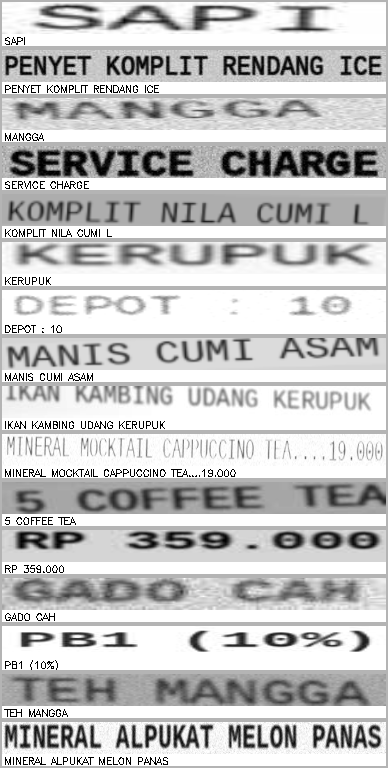

CHARSET: 0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ .,:-/()%& | jumlah kelas: 46


In [ ]:
# ============================================================
# CELL A — Generator synthetic text-line nota Indonesia (untuk CRNN baru)
# ============================================================
!pip install -q pillow numpy opencv-python-headless
import random, numpy as np, cv2
from PIL import Image, ImageDraw, ImageFont
from google.colab.patches import cv2_imshow

CHARSET = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ .,:-/()%&"   # uppercase-only + simbol struk

FONTS = [
    "/usr/share/fonts/truetype/dejavu/DejaVuSansMono.ttf",
    "/usr/share/fonts/truetype/dejavu/DejaVuSansMono-Bold.ttf",
    "/usr/share/fonts/truetype/liberation/LiberationMono-Regular.ttf",
    "/usr/share/fonts/truetype/liberation/LiberationMono-Bold.ttf",
]
FONTS = [f for f in FONTS if __import__("os").path.exists(f)]
if not FONTS: FONTS = ["/usr/share/fonts/truetype/dejavu/DejaVuSansMono.ttf"]

FOOD = ["NASI","GORENG","AYAM","BAKAR","SAPI","SAMBAL","SOTO","MIE","BAKSO","SATE","GADO",
        "RENDANG","IKAN","UDANG","CUMI","TAHU","TEMPE","TELUR","CAPCAY","KANGKUNG","BEBEK",
        "KAMBING","GURAME","LELE","NILA","KAKAP","SOP","TUMIS","PECEL","LALAPAN","KERUPUK",
        "KENTANG","JAMUR","CRISPY","GEPREK","PENYET","BALI","PADANG","KREMES","ASAM","MANIS",
        "PEDAS","SPESIAL","KOMPLIT","PAKET","CAH","BROKOLI","SEAFOOD","KEPITING","FILLET"]
DRINK = ["ES","TEH","KOPI","JUS","TEA","COFFEE","SUSU","JERUK","LEMON","MILK","LATTE",
         "CAPPUCCINO","AMERICANO","MATCHA","COKLAT","ALPUKAT","MANGGA","MELON","JAMBU",
         "SODA","AIR","MINERAL","LYCHEE","THAI","TARIK","TUBRUK","PANAS","DINGIN","FLOAT","MOCKTAIL"]
MOD = ["S","M","L","REG","LARGE","SMALL","JUMBO","MINI","HOT","ICE","ORIGINAL","SPESIAL","1","2","3"]
LABELS = ["SUBTOTAL","SUB TOTAL","TOTAL","GRAND TOTAL","PAJAK","PPN","PB1","TAX","SERVICE",
          "SERVICE CHARGE","SVC","DISCOUNT","DISKON","TUNAI","CASH","KEMBALI","CHANGE","NETTO",
          "BAYAR","TOTAL BAYAR","PPN 10%","PB1 (10%)","SC (5%)","PB1 10%","SERVICE 5%"]
HEADERS = ["TERIMA KASIH","SELAMAT DATANG","PAX","MEJA","NO","KASIR","TANGGAL","JAM",
           "STRUK PEMBELIAN","NOTA","ORDER","RESTORAN","CAFE","WARUNG","DEPOT","RUMAH MAKAN"]

def money():
    v = random.choice([random.randint(3,99)*1000, random.randint(10,50)*100,
                       random.randint(100,500)*1000, random.randint(1,30)*1000])
    sep = random.choice([".",","]); s = f"{v:,}".replace(",", sep)
    if random.random()<0.25: s += random.choice([sep+"00", ",00", ".00"])
    if random.random()<0.30: s = ("RP " if random.random()<0.5 else "RP") + s
    return s

def menu_name():
    pool = FOOD if random.random()<0.6 else DRINK
    words = [random.choice(pool) for _ in range(random.randint(1,4))]
    if random.random()<0.4: words.append(random.choice(MOD))
    return " ".join(words)

def gen_text():
    r = random.random()
    if   r<0.42: return menu_name()
    elif r<0.66: return money()
    elif r<0.78: return f"{random.randint(1,5)}{random.choice(['','X',' X',' '])} {menu_name()}".strip()
    elif r<0.88: return random.choice(LABELS)
    elif r<0.95:
        gap = random.choice(["  "," "*random.randint(2,8), "."*random.randint(2,10)])
        return f"{menu_name()}{gap}{money()}"
    else:
        h = random.choice(HEADERS)
        if random.random()<0.5: h += random.choice([" : "+str(random.randint(1,20)), " 29/04/2026", " 19:45", ""])
        return h

def filter_charset(t): return "".join(c for c in t if c in CHARSET)

def render(text, font_path, fsize):
    font = ImageFont.truetype(font_path, fsize); bbox = font.getbbox(text)
    w = bbox[2]-bbox[0]+random.randint(6,20); h = bbox[3]-bbox[1]+random.randint(6,16)
    img = Image.new("L",(max(w,10),max(h,20)),color=random.randint(225,255))
    ImageDraw.Draw(img).text((random.randint(2,6)-bbox[0],random.randint(2,6)-bbox[1]),
                             text, fill=random.randint(0,60), font=font)
    return np.array(img)

def augment(img):
    h,w = img.shape
    if random.random()<0.6:
        sh=random.uniform(-0.08,0.08); ang=random.uniform(-2.5,2.5)
        img=cv2.warpAffine(img,np.float32([[1,sh,0],[0,1,0]]),(w,h),borderValue=240)
        img=cv2.warpAffine(img,cv2.getRotationMatrix2D((w/2,h/2),ang,1),(w,h),borderValue=240)
    if random.random()<0.5:
        k=np.ones((random.choice([1,2]),random.choice([1,2])),np.uint8)
        img=cv2.erode(img,k) if random.random()<0.5 else cv2.dilate(img,k)
    if random.random()<0.7:
        f=random.uniform(0.5,0.9); img=cv2.resize(img,(max(2,int(w*f)),max(2,int(h*f)))); img=cv2.resize(img,(w,h))
    if random.random()<0.5: img=cv2.GaussianBlur(img,(0,0),random.uniform(0.4,1.3))
    img=np.clip(img.astype(np.float32)*random.uniform(0.7,1.15)+random.uniform(-25,15),0,255).astype(np.uint8)
    if random.random()<0.6: img=np.clip(img.astype(np.float32)+np.random.normal(0,random.uniform(4,18),img.shape),0,255).astype(np.uint8)
    if random.random()<0.3:
        grad=np.linspace(random.uniform(0,40),random.uniform(0,40),w)[None,:]
        img=np.clip(img.astype(np.float32)+grad,0,255).astype(np.uint8)
    if random.random()<0.4:
        _,enc=cv2.imencode(".jpg",img,[cv2.IMWRITE_JPEG_QUALITY,random.randint(30,75)]); img=cv2.imdecode(enc,0)
    return img

def sample():
    text=filter_charset(gen_text().upper())
    if not text.strip(): text="NASI GORENG"
    return augment(render(text,random.choice(FONTS),random.randint(22,34))), text

# ── Preview ──
random.seed(7); rows=[]
for _ in range(16):
    im,txt=sample(); im=cv2.resize(im,(384,32))
    c=np.full((44,384),255,np.uint8); c[:32]=im
    cv2.putText(c,txt[:42],(2,42),cv2.FONT_HERSHEY_SIMPLEX,0.32,0,1); rows.append(c)
cv2_imshow(np.vstack([np.pad(r,((2,2),(2,2)),constant_values=180) for r in rows]))
print("CHARSET:", CHARSET, "| jumlah kelas:", len(CHARSET))

In [ ]:
# ============================================================
# CELL B — Ekstrak crop teks ASLI dari CORD (untuk campuran training CRNN)
# Butuh CHARSET dari CELL A. Output: real_crops.npz di Drive.
# ============================================================
!pip install -q datasets
import json, numpy as np, cv2
from datasets import load_dataset
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

def clean(t):
    return "".join(c for c in t.upper() if c in CHARSET).strip()

def quad_box(q):
    xs = [q['x1'],q['x2'],q['x3'],q['x4']]; ys=[q['y1'],q['y2'],q['y3'],q['y4']]
    return int(min(xs)), int(min(ys)), int(max(xs)), int(max(ys))

imgs, labels = [], []
SPLITS = ["train","validation","test"]
for sp in SPLITS:
    ds = load_dataset("naver-clova-ix/cord-v2", split=sp)
    print(f"[{sp}] {len(ds)} nota...")
    for ex in ds:
        img = np.array(ex["image"].convert("L"))
        H,W = img.shape
        gt = json.loads(ex["ground_truth"])
        for line in gt.get("valid_line", []):
            words = line.get("words", [])
            # ── crop per KATA ──
            line_boxes = []
            for w in words:
                t = clean(w.get("text",""))
                q = w.get("quad")
                if not t or not q: continue
                x1,y1,x2,y2 = quad_box(q)
                x1,y1 = max(0,x1),max(0,y1); x2,y2 = min(W,x2),min(H,y2)
                if x2-x1<4 or y2-y1<4: continue
                crop = img[y1:y2, x1:x2]
                imgs.append(cv2.resize(crop,(384,32))); labels.append(t)
                line_boxes.append((x1,y1,x2,y2,t))
            # ── crop per BARIS (gabungan kata) ──
            if len(line_boxes) >= 2:
                xs1=[b[0] for b in line_boxes]; ys1=[b[1] for b in line_boxes]
                xs2=[b[2] for b in line_boxes]; ys2=[b[3] for b in line_boxes]
                lx1,ly1,lx2,ly2 = min(xs1),min(ys1),max(xs2),max(ys2)
                if lx2-lx1>4 and ly2-ly1>4:
                    crop = img[ly1:ly2, lx1:lx2]
                    txt = clean(" ".join(b[4] for b in sorted(line_boxes,key=lambda b:b[0])))
                    if txt:
                        imgs.append(cv2.resize(crop,(384,32))); labels.append(txt)

imgs = np.array(imgs, dtype=np.uint8)
print(f"\nTotal crop asli: {len(imgs)}  | shape: {imgs.shape}")
print("Contoh label:", labels[:12])

np.savez_compressed("/content/drive/MyDrive/real_crops.npz",
                    images=imgs, labels=np.array(labels, dtype=object))
print("Disimpan -> /content/drive/MyDrive/real_crops.npz")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/27.0 [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

data/train-00000-of-00004-b4aaeceff1d90e(…):   0%|          | 0.00/490M [00:00<?, ?B/s]

...

data/test-00000-of-00001-9c204eb3f4e1179(…):   0%|          | 0.00/234M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/800 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/100 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/100 [00:00<?, ? examples/s]

[train] 800 nota...
[validation] 100 nota...
[test] 100 nota...

Total crop asli: 30804  | shape: (30804, 32, 384)
Contoh label: ['1', 'X', '1 X', 'NASI', 'CAMPUR', 'BALI', 'NASI CAMPUR BALI', '75,000', '1', 'X', '1 X', 'BBK']
Disimpan -> /content/drive/MyDrive/real_crops.npz


In [ ]:
# ============================================================
# CELL C — Training CRNN + CTC from scratch (synthetic + CORD asli)
# Butuh: CELL A (sample, CHARSET) sudah dijalankan + real_crops.npz
# ============================================================
import random, numpy as np, cv2, torch, torch.nn as nn, os, time
from torch.utils.data import Dataset, DataLoader

dev = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", dev)
assert dev=="cuda", "Nyalakan GPU dulu (Runtime > Change runtime type > T4 GPU)"

char2idx = {c:i+1 for i,c in enumerate(CHARSET)}   # 0 = blank
idx2char = {i+1:c for i,c in enumerate(CHARSET)}
NUM_CLASSES = len(CHARSET)+1

# ── Model ──
class CRNN(nn.Module):
    def __init__(self, n_cls, ch=1):
        super().__init__()
        def conv(i,o,k=3,s=1,p=1,bn=False):
            L=[nn.Conv2d(i,o,k,s,p),nn.ReLU(True)]
            if bn: L.insert(1,nn.BatchNorm2d(o))
            return L
        self.cnn=nn.Sequential(*conv(ch,64),nn.MaxPool2d(2,2),*conv(64,128),nn.MaxPool2d(2,2),
            *conv(128,256,bn=True),*conv(256,256),nn.MaxPool2d((2,1),(2,1)),
            *conv(256,512,bn=True),*conv(512,512),nn.MaxPool2d((2,1),(2,1)),
            *conv(512,512,k=2,s=1,p=0,bn=True))
        self.rnn=nn.LSTM(512,256,bidirectional=True,num_layers=2,batch_first=True,dropout=0.2)
        self.fc=nn.Linear(512,n_cls)
    def forward(self,x):
        c=self.cnn(x); c=c.squeeze(2).permute(0,2,1); r,_=self.rnn(c); return self.fc(r)

# ── Data ──
data = np.load("/content/drive/MyDrive/real_crops.npz", allow_pickle=True)
real_imgs, real_labels = data["images"], data["labels"]
idx = np.arange(len(real_imgs)); np.random.seed(0); np.random.shuffle(idx)
nval = int(len(idx)*0.05)
val_idx, tr_idx = idx[:nval], idx[nval:]
print(f"Real crops: train {len(tr_idx)}, val {len(val_idx)}")

def light_aug(img):
    if random.random()<0.4: img=cv2.GaussianBlur(img,(0,0),random.uniform(0.3,0.9))
    if random.random()<0.4: img=np.clip(img.astype(np.float32)+np.random.normal(0,8,img.shape),0,255).astype(np.uint8)
    return img
def to_tensor(img):
    a=(img.astype(np.float32)/255.0-0.5)/0.5; return torch.from_numpy(a)[None]
def encode(txt): return [char2idx[c] for c in txt if c in char2idx]

class OCRDataset(Dataset):
    def __init__(self, length, p_synth=0.55, train=True, vidx=None):
        self.length=length; self.p=p_synth; self.train=train; self.vidx=vidx
    def __len__(self): return self.length if self.train else len(self.vidx)
    def __getitem__(self,i):
        if self.train and random.random()<self.p:
            img,txt = sample(); img=cv2.resize(img,(384,32))
        else:
            j = random.choice(tr_idx) if self.train else self.vidx[i]
            img=real_imgs[j].copy(); txt=str(real_labels[j])
            if self.train: img=light_aug(img)
        lab=encode(txt)
        if not lab: lab=encode("NASI"); txt="NASI"
        return to_tensor(img), torch.tensor(lab), len(lab), txt

def collate(b):
    return (torch.stack([x[0] for x in b]), torch.cat([x[1] for x in b]),
            torch.tensor([x[2] for x in b]), [x[3] for x in b])

EPOCH_STEPS=24000; BATCH=64; EPOCHS=25
tr_dl=DataLoader(OCRDataset(EPOCH_STEPS,train=True),batch_size=BATCH,collate_fn=collate,
                 num_workers=4,shuffle=False,persistent_workers=True)
va_dl=DataLoader(OCRDataset(0,train=False,vidx=val_idx),batch_size=BATCH,collate_fn=collate,num_workers=2)

def edit_distance(a,b):
    m,n=len(a),len(b); dp=list(range(n+1))
    for i in range(1,m+1):
        prev=dp[0]; dp[0]=i
        for j in range(1,n+1):
            cur=dp[j]; dp[j]=min(dp[j]+1,dp[j-1]+1,prev+(a[i-1]!=b[j-1])); prev=cur
    return dp[n]
def greedy(logits):
    idx=logits.argmax(2); outs=[]
    for seq in idx:
        prev=0; s=""
        for k in seq.tolist():
            if k!=0 and k!=prev: s+=idx2char.get(k,"")
            prev=k
        outs.append(s)
    return outs

model=CRNN(NUM_CLASSES).to(dev)
opt=torch.optim.AdamW(model.parameters(),lr=1e-3,weight_decay=1e-4)
sched=torch.optim.lr_scheduler.OneCycleLR(opt,max_lr=1e-3,epochs=EPOCHS,steps_per_epoch=len(tr_dl))
ctc=nn.CTCLoss(blank=0,zero_infinity=True)
scaler=torch.cuda.amp.GradScaler()

CKPT="/content/drive/MyDrive/crnn_v2_best.pth"
START=0; best=9.9
if os.path.exists(CKPT):
    ck=torch.load(CKPT,map_location=dev)
    model.load_state_dict(ck["model"]); best=ck.get("cer",9.9); START=ck.get("epoch",0)
    print(f"Resume dari epoch {START}, best CER {best:.4f}")

for ep in range(START,EPOCHS):
    model.train(); t0=time.time(); tot=0
    for imgs,tgts,tl,_ in tr_dl:
        imgs=imgs.to(dev)
        with torch.cuda.amp.autocast():
            out=model(imgs)
        out=out.float(); logp=out.log_softmax(2).permute(1,0,2)
        il=torch.full((imgs.size(0),),out.size(1),dtype=torch.long)
        loss=ctc(logp,tgts,il,tl)
        opt.zero_grad(); scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); sched.step()
        tot+=loss.item()
    # val
    model.eval(); cers=[]
    with torch.no_grad():
        for imgs,tgts,tl,txts in va_dl:
            preds=greedy(model(imgs.to(dev)).cpu())
            cers+=[edit_distance(p,t)/max(1,len(t)) for p,t in zip(preds,txts)]
    cer=float(np.mean(cers))
    print(f"Epoch {ep+1}/{EPOCHS} | loss {tot/len(tr_dl):.3f} | val CER {cer:.4f} | {time.time()-t0:.0f}s")
    if cer<best:
        best=cer
        torch.save({"model":model.state_dict(),"cer":cer,"epoch":ep+1,"charset":CHARSET}, CKPT)
        print(f"  ✓ best disimpan (CER {cer:.4f})")

print("SELESAI. Best CER:", round(best,4), "->", CKPT)

Device: cuda
Real crops: train 29264, val 1540


/tmp/ipykernel_512/2876375959.py:94: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler=torch.cuda.amp.GradScaler()
/tmp/ipykernel_512/2876375959.py:107: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_512/2876375959.py:112: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  opt.zero_grad(); scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); sched.step()


Epoch 1/25 | loss 8.631 | val CER 1.0000 | 15s
  ✓ best disimpan (CER 1.0000)
Epoch 2/25 | loss 3.378 | val CER 1.0000 | 13s
Epoch 3/25 | loss 2.170 | val CER 0.3795 | 13s
  ✓ best disimpan (CER 0.3795)
Epoch 4/25 | loss 0.515 | val CER 0.1715 | 13s
  ✓ best disimpan (CER 0.1715)
Epoch 5/25 | loss 0.297 | val CER 0.1562 | 13s
  ✓ best disimpan (CER 0.1562)
Epoch 6/25 | loss 0.236 | val CER 0.1164 | 13s
  ✓ best disimpan (CER 0.1164)
Epoch 7/25 | loss 0.222 | val CER 0.1035 | 13s
  ✓ best disimpan (CER 0.1035)
Epoch 8/25 | loss 0.175 | val CER 0.1027 | 12s
  ✓ best disimpan (CER 0.1027)
Epoch 9/25 | loss 0.134 | val CER 0.0732 | 13s
  ✓ best disimpan (CER 0.0732)
Epoch 10/25 | loss 0.138 | val CER 0.0686 | 13s
  ✓ best disimpan (CER 0.0686)
Epoch 11/25 | loss 0.122 | val CER 0.0616 | 12s
  ✓ best disimpan (CER 0.0616)
Epoch 12/25 | loss 0.103 | val CER 0.0569 | 12s
  ✓ best disimpan (CER 0.0569)
Epoch 13/25 | loss 0.115 | val CER 0.0520 | 12s
  ✓ best disimpan (CER 0.0520)
Epoch 14/25 |

In [ ]:
# ============================================================
# CELL D — Evaluasi CRNN baru: lihat prediksi vs jawaban + CER
# Butuh: CELL C sudah jalan (model, CHARSET, greedy, edit_distance, dll)
# ============================================================
import numpy as np, torch, random

ck = torch.load("/content/drive/MyDrive/crnn_v2_best.pth", map_location=dev)
model.load_state_dict(ck["model"]); model.eval()
print(f"Loaded best CRNN (CER {ck['cer']:.4f}, epoch {ck['epoch']})\n")

# ambil sampel dari val crops
data = np.load("/content/drive/MyDrive/real_crops.npz", allow_pickle=True)
ri, rl = data["images"], data["labels"]
random.seed(1); pick = random.sample(list(val_idx), 30)

num_cer, alpha_cer = [], []
print(f"{'JAWABAN':<28} {'PREDIKSI CRNN':<28} OK")
print("-"*64)
with torch.no_grad():
    for j in pick:
        img = ri[j]; gold = str(rl[j])
        t = to_tensor(img).unsqueeze(0).to(dev)
        pred = greedy(model(t).cpu())[0]
        ok = "✓" if pred==gold else "✗"
        print(f"{gold[:27]:<28} {pred[:27]:<28} {ok}")
        c = edit_distance(pred,gold)/max(1,len(gold))
        (num_cer if gold.replace(',','').replace('.','').isdigit() else alpha_cer).append(c)

print("-"*64)
print(f"CER angka (harga): {np.mean(num_cer) if num_cer else 0:.4f}")
print(f"CER teks (nama)  : {np.mean(alpha_cer) if alpha_cer else 0:.4f}")

Loaded best CRNN (CER 0.0242, epoch 23)

JAWABAN                      PREDIKSI CRNN                OK
----------------------------------------------------------------
SUBTOTAL                     SUBTOTAL                     ✓
COMBO                        COMBO                        ✓
PL. MUFFIN BLUEBERRY         PL. MUFFIN BLUEBERRY         ✓
CHANGE 1.200                 CHANGE 1.200                 ✓
GREEN                        GREEN                        ✓
AMOUNT                       AMOUNT                       ✓
365,000                      365,000                      ✓
T-CASH 23.000                T-CASH 23.000                ✓
QTY                          QTY                          ✓
%                            %                            ✓
22,000                       22,000                       ✓
CHANGE: 14.000               CHANGE: 16.000               ✗
PAKET                        PAKET                        ✓
35,000                       35,000                  

In [ ]:
# ============================================================
# CELL E — Export CRNN baru ke OpenVINO (untuk deploy ke Space)
# Butuh: CELL C jalan (model, CRNN, NUM_CLASSES, CHARSET, dev)
# ============================================================
!pip install -q openvino onnx onnxscript
import torch, os

ck = torch.load("/content/drive/MyDrive/crnn_v2_best.pth", map_location=dev)
model.load_state_dict(ck["model"]); model.eval().cpu()
print(f"Export model CER {ck['cer']:.4f}")

# 1) export ke ONNX dulu (input 1x1x32x384)
dummy = torch.randn(1,1,32,384)
torch.onnx.export(model, dummy, "/content/crnn_v2.onnx",
    input_names=["input"], output_names=["output"],
    dynamic_axes={"input":{0:"batch"}, "output":{0:"batch"}}, opset_version=12)
print("ONNX OK")

# 2) ONNX -> OpenVINO IR
import openvino as ov
ov_model = ov.convert_model("/content/crnn_v2.onnx")
ov.save_model(ov_model, "/content/drive/MyDrive/crnn_model.xml")   # langsung pakai nama lama
print("OpenVINO IR tersimpan: crnn_model.xml + .bin di Drive")

# 3) verifikasi hasil OpenVINO == hasil torch
import numpy as np
core = ov.Core(); comp = core.compile_model(ov_model, "CPU")
test = np.random.randn(1,1,32,384).astype(np.float32)
ov_out = comp(test)[comp.output(0)]
with torch.no_grad(): pt_out = model(torch.from_numpy(test)).numpy()
print("Selisih OV vs Torch (harus ~0):", np.abs(ov_out-pt_out).max())
print("Output shape:", ov_out.shape)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 140.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 19.8 MB/s eta 0:00:00
Export model CER 0.0242


/tmp/ipykernel_512/2249786931.py:14: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(model, dummy, "/content/crnn_v2.onnx",
W0630 14:58:58.851000 512 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 12 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `CRNN([...]` with `torch.export.export(..., strict=False)`...


/usr/lib/python3.12/contextlib.py:144: UserWarning: The tensor attributes self.rnn._flat_weights[0], self.rnn._flat_weights[1], self.rnn._flat_weights[2], self.rnn._flat_weights[3], self.rnn._flat_weights[4], self.rnn._flat_weights[5], self.rnn._flat_weights[6], self.rnn._flat_weights[7], self.rnn._flat_weights[8], self.rnn._flat_weights[9], self.rnn._flat_weights[10], self.rnn._flat_weights[11], self.rnn._flat_weights[12], self.rnn._flat_weights[13], self.rnn._flat_weights[14], self.rnn._flat_weights[15] were assigned during export. Such attributes must be registered as buffers using the `register_buffer` API (https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.register_buffer).
  next(self.gen)


[torch.onnx] Obtain model graph for `CRNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
ONNX OK
OpenVINO IR tersimpan: crnn_model.xml + .bin di Drive
Selisih OV vs Torch (harus ~0): 8.583069e-06
Output shape: (1, 95, 47)


In [ ]:
# ============================================================
# CELL F — Evaluasi CRNN: hitung WAR + CAR + CER untuk Tabel 4.1
# Self-contained. Butuh: crnn_v2_best.pth + real_crops.npz di Drive.
# ============================================================
import numpy as np, torch, torch.nn as nn
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

CHARSET = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ .,:-/()%&"
idx2char = {i+1:c for i,c in enumerate(CHARSET)}
NUM_CLASSES = len(CHARSET)+1
dev = "cuda" if torch.cuda.is_available() else "cpu"

class CRNN(nn.Module):
    def __init__(self,n_cls,ch=1):
        super().__init__()
        def conv(i,o,k=3,s=1,p=1,bn=False):
            L=[nn.Conv2d(i,o,k,s,p),nn.ReLU(True)]
            if bn: L.insert(1,nn.BatchNorm2d(o))
            return L
        self.cnn=nn.Sequential(*conv(ch,64),nn.MaxPool2d(2,2),*conv(64,128),nn.MaxPool2d(2,2),
            *conv(128,256,bn=True),*conv(256,256),nn.MaxPool2d((2,1),(2,1)),
            *conv(256,512,bn=True),*conv(512,512),nn.MaxPool2d((2,1),(2,1)),
            *conv(512,512,k=2,s=1,p=0,bn=True))
        self.rnn=nn.LSTM(512,256,bidirectional=True,num_layers=2,batch_first=True,dropout=0.2)
        self.fc=nn.Linear(512,n_cls)
    def forward(self,x):
        c=self.cnn(x); c=c.squeeze(2).permute(0,2,1); r,_=self.rnn(c); return self.fc(r)

model=CRNN(NUM_CLASSES).to(dev)
ck=torch.load("/content/drive/MyDrive/crnn_v2_best.pth",map_location=dev)
model.load_state_dict(ck["model"]); model.eval()

data=np.load("/content/drive/MyDrive/real_crops.npz",allow_pickle=True)
ri,rl=data["images"],data["labels"]
idx=np.arange(len(ri)); np.random.seed(0); np.random.shuffle(idx)
val_idx=idx[:int(len(idx)*0.05)]   # data uji yang disisihkan (sama seperti training)

def to_tensor(img):
    a=(img.astype(np.float32)/255.0-0.5)/0.5; return torch.from_numpy(a)[None]
def greedy(logits):
    seq=logits.argmax(2)[0].tolist(); prev=0; s=""
    for k in seq:
        if k!=0 and k!=prev: s+=idx2char.get(k,"")
        prev=k
    return s
def edit(a,b):
    m,n=len(a),len(b); dp=list(range(n+1))
    for i in range(1,m+1):
        pr=dp[0]; dp[0]=i
        for j in range(1,n+1):
            cu=dp[j]; dp[j]=min(dp[j]+1,dp[j-1]+1,pr+(a[i-1]!=b[j-1])); pr=cu
    return dp[n]

exact=0; tot_char=0; tot_err=0; N=len(val_idx)
with torch.no_grad():
    for j in val_idx:
        gold=str(rl[j])
        pred=greedy(model(to_tensor(ri[j]).unsqueeze(0).to(dev)).cpu())
        if pred==gold: exact+=1
        tot_err+=edit(pred,gold); tot_char+=max(1,len(gold))

WAR=exact/N; CER=tot_err/tot_char; CAR=1-CER
print(f"Jumlah data uji : {N} potongan teks")
print(f"WAR (Word Acc)  : {WAR*100:.1f}%")
print(f"CAR (Char Acc)  : {CAR*100:.2f}%")
print(f"CER (Char Err)  : {CER:.4f}  ({CER*100:.2f}%)")

Mounted at /content/drive
Jumlah data uji : 1540 potongan teks
WAR (Word Acc)  : 89.7%
CAR (Char Acc)  : 95.88%
CER (Char Err)  : 0.0412  (4.12%)


Mounted at /content/drive
Jumlah data uji : 1540 potongan teks
WAR : 89.7%   CAR : 95.88%   CER : 4.12%


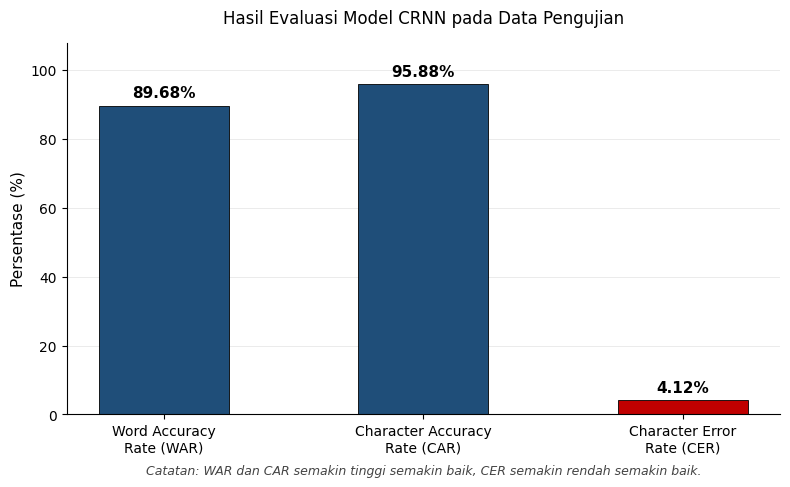


Grafik tersimpan di Drive: grafik_evaluasi_crnn.png


In [ ]:
# ============================================================
# CELL H — Evaluasi CRNN (WAR, CAR, CER) + Grafik
# Butuh: crnn_v2_best.pth & real_crops.npz di Drive
# ============================================================
!pip install -q matplotlib
import numpy as np, torch, torch.nn as nn
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

CHARSET = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ .,:-/()%&"
idx2char = {i+1: c for i, c in enumerate(CHARSET)}
NUM_CLASSES = len(CHARSET) + 1
dev = "cuda" if torch.cuda.is_available() else "cpu"

class CRNN(nn.Module):
    def __init__(self, n_cls, ch=1):
        super().__init__()
        def conv(i,o,k=3,s=1,p=1,bn=False):
            L=[nn.Conv2d(i,o,k,s,p), nn.ReLU(True)]
            if bn: L.insert(1, nn.BatchNorm2d(o))
            return L
        self.cnn = nn.Sequential(*conv(ch,64), nn.MaxPool2d(2,2), *conv(64,128), nn.MaxPool2d(2,2),
            *conv(128,256,bn=True), *conv(256,256), nn.MaxPool2d((2,1),(2,1)),
            *conv(256,512,bn=True), *conv(512,512), nn.MaxPool2d((2,1),(2,1)),
            *conv(512,512,k=2,s=1,p=0,bn=True))
        self.rnn = nn.LSTM(512,256,bidirectional=True,num_layers=2,batch_first=True,dropout=0.2)
        self.fc  = nn.Linear(512, n_cls)
    def forward(self,x):
        c=self.cnn(x); c=c.squeeze(2).permute(0,2,1); r,_=self.rnn(c); return self.fc(r)

model = CRNN(NUM_CLASSES).to(dev)
ck = torch.load("/content/drive/MyDrive/crnn_v2_best.pth", map_location=dev)
model.load_state_dict(ck["model"]); model.eval()

data = np.load("/content/drive/MyDrive/real_crops.npz", allow_pickle=True)
ri, rl = data["images"], data["labels"]
idx = np.arange(len(ri)); np.random.seed(0); np.random.shuffle(idx)
val_idx = idx[:int(len(idx)*0.05)]

def to_tensor(img):
    a = (img.astype(np.float32)/255.0 - 0.5)/0.5
    return torch.from_numpy(a)[None]

def greedy(logits):
    seq = logits.argmax(2)[0].tolist(); prev=0; s=""
    for k in seq:
        if k != 0 and k != prev: s += idx2char.get(k,"")
        prev = k
    return s

def edit(a,b):
    m,n=len(a),len(b); dp=list(range(n+1))
    for i in range(1,m+1):
        pr=dp[0]; dp[0]=i
        for j in range(1,n+1):
            cu=dp[j]; dp[j]=min(dp[j]+1, dp[j-1]+1, pr+(a[i-1]!=b[j-1])); pr=cu
    return dp[n]

exact=0; tot_char=0; tot_err=0; N=len(val_idx)
with torch.no_grad():
    for j in val_idx:
        gold = str(rl[j])
        pred = greedy(model(to_tensor(ri[j]).unsqueeze(0).to(dev)).cpu())
        if pred == gold: exact += 1
        tot_err += edit(pred, gold); tot_char += max(1, len(gold))

WAR = exact/N*100
CER = tot_err/tot_char*100
CAR = 100 - CER

print(f"Jumlah data uji : {N} potongan teks")
print(f"WAR : {WAR:.1f}%   CAR : {CAR:.2f}%   CER : {CER:.2f}%")

# ---------- GRAFIK ----------
fig, ax = plt.subplots(figsize=(8,5))
labels = ["Word Accuracy\nRate (WAR)", "Character Accuracy\nRate (CAR)", "Character Error\nRate (CER)"]
vals   = [WAR, CAR, CER]
colors = ["#1f4e79", "#1f4e79", "#c00000"]

bars = ax.bar(labels, vals, color=colors, width=0.5, edgecolor="black", linewidth=0.6)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v+1.5, f"{v:.2f}%", ha="center", va="bottom",
            fontsize=11, fontweight="bold")

ax.set_ylabel("Persentase (%)", fontsize=11)
ax.set_ylim(0, 108); ax.set_yticks(range(0,101,20))
ax.grid(axis="y", alpha=0.25, linewidth=0.7); ax.set_axisbelow(True)
ax.spines[["top","right"]].set_visible(False)
ax.set_title("Hasil Evaluasi Model CRNN pada Data Pengujian", fontsize=12, pad=14)
ax.text(0.5, -0.16, "Catatan: WAR dan CAR semakin tinggi semakin baik, CER semakin rendah semakin baik.",
        transform=ax.transAxes, ha="center", fontsize=9, style="italic", color="#444")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/grafik_evaluasi_crnn.png", dpi=200, facecolor="white", bbox_inches="tight")
plt.show()
print("\nGrafik tersimpan di Drive: grafik_evaluasi_crnn.png")

In [ ]:
# ============================================================
# CELL — Pengujian CRNN pada CORD v2 test (per word crop)
# Pakai anotasi koordinat resmi CORD — tidak perlu EasyOCR
# ============================================================

!pip install -q editdistance datasets

import json, editdistance
import numpy as np, torch
from datasets import load_dataset
from PIL import Image

print("Memuat 100 sampel CORD v2 test...")
cord = load_dataset("naver-clova-ix/cord-v2", split="test").select(range(100))

def preprocess_crop(crop_pil):
    img = crop_pil.convert("L").resize((384, 32), Image.LANCZOS)
    arr = (np.array(img, dtype=np.float32) / 255.0 - 0.5) / 0.5
    return torch.from_numpy(arr).unsqueeze(0).unsqueeze(0)

def greedy_decode(logits):
    seq = logits.argmax(2)[0].tolist()
    prev, s = 0, ""
    for k in seq:
        if k != 0 and k != prev:
            s += idx2char.get(k, "")
        prev = k
    return s

total_err = 0
total_chars = 0
exact_words = 0
total_words = 0

print("Menguji per kata menggunakan koordinat anotasi CORD...")
model.eval()

with torch.no_grad():
    for i, sample in enumerate(cord):
        gt = json.loads(sample["ground_truth"])
        pil_img = sample["image"].convert("RGB")
        w_img, h_img = pil_img.size

        for line in gt.get("valid_line", []):
            for word in line.get("words", []):
                text = word.get("text", "").strip().upper()
                quad = word.get("quad", {})
                if not text or not quad:
                    continue

                # filter karakter di luar charset 46
                text_filtered = "".join(
                    c for c in text
                    if c in "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ .,:-/()%&"
                )
                if not text_filtered:
                    continue

                # crop dari koordinat anotasi
                x1 = int(min(quad.get("x1",0), quad.get("x4",0)))
                x2 = int(max(quad.get("x2",0), quad.get("x3",0)))
                y1 = int(min(quad.get("y1",0), quad.get("y2",0)))
                y2 = int(max(quad.get("y3",0), quad.get("y4",0)))
                x1,y1 = max(0,x1), max(0,y1)
                x2,y2 = min(w_img,x2), min(h_img,y2)

                if x2 - x1 < 5 or y2 - y1 < 5:
                    continue

                try:
                    crop = pil_img.crop((x1, y1, x2, y2))
                    inp = preprocess_crop(crop).to(dev)
                    logits = model(inp).cpu()
                    pred = greedy_decode(logits)
                except:
                    continue

                err = editdistance.eval(pred, text_filtered)
                total_err += err
                total_chars += max(1, len(text_filtered))
                if pred == text_filtered:
                    exact_words += 1
                total_words += 1

        if i % 20 == 0:
            print(f"  [{i+1}/100] gambar diproses, total kata sejauh ini: {total_words}")

CER = total_err / total_chars * 100
CAR = 100 - CER
WAR = exact_words / max(1, total_words) * 100

print(f"\n=== HASIL PENGUJIAN CRNN PADA CORD v2 TEST (PER KATA) ===")
print(f"Total kata diuji  : {total_words}")
print(f"WAR               : {WAR:.1f}%")
print(f"CAR               : {CAR:.2f}%")
print(f"CER               : {CER:.2f}%")
print(f"\nBandingkan dengan data CORD v2 crops (training split):")
print(f"WAR : 89.7%  →  {WAR:.1f}%")
print(f"CER : 4.12%  →  {CER:.2f}%")

Memuat 100 sampel CORD v2 test...
Menguji per kata menggunakan koordinat anotasi CORD...
  [1/100] gambar diproses, total kata sejauh ini: 23
  [21/100] gambar diproses, total kata sejauh ini: 448
  [41/100] gambar diproses, total kata sejauh ini: 952
  [61/100] gambar diproses, total kata sejauh ini: 1425
  [81/100] gambar diproses, total kata sejauh ini: 1874

=== HASIL PENGUJIAN CRNN PADA CORD v2 TEST (PER KATA) ===
Total kata diuji  : 2348
WAR               : 96.3%
CAR               : 99.04%
CER               : 0.96%

Bandingkan dengan data CORD v2 crops (training split):
WAR : 89.7%  →  96.3%
CER : 4.12%  →  0.96%
